## Notes

In [265]:
# can travel for 1/4 sq km in 1hr - 1 flight
# each sq km is 18,000rs

In [266]:
INDIA_PROJECTED_CRS = "24378"

## Setup

In [267]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [268]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import openpyxl

import matplotlib.pyplot as plt

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

In [269]:
from gridsample.utils import save_shapefiles
# from gridsample.mapping.plot import create_interactive_map

In [270]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Goverment Buildings"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

CONSOLIDATED_DATA_PATH = (
    RAW_DATA_DIR / "government_buildings" / "Consolidated_data_09042025.xlsx"
)

In [271]:
workbook = openpyxl.load_workbook(CONSOLIDATED_DATA_PATH)

## Utilities

In [272]:
def is_cell_highlighted(cell):
    if cell.fill.fill_type == "solid":
        # Check if the cell has a background color (not white/none)
        if (
            cell.fill.start_color.rgb != "00000000"
            and cell.fill.start_color.rgb != "FFFFFFFF"
        ):
            return True
    return False


def get_highlighted_rows(worksheet):
    highlighted_rows = []

    for row_idx, row in enumerate(worksheet.iter_rows(min_row=2)):  # Skip header row
        if sum(is_cell_highlighted(cell) for cell in row) >= 24:
            highlighted_rows.append(row_idx)

    return highlighted_rows

## Load the secondary data source - East Zone DISCOMs data
For backup latlons.

In [273]:
df_east_discom_1 = pd.read_excel(
    RAW_DATA_DIR
    / "government_buildings"
    / "East Zone DISCOM data - 10 KW and Above EZ.xlsx",
    sheet_name="10 KW and above(LV1,2,4,5) ",
    header=0,
)

df_east_discom_2 = pd.read_excel(
    RAW_DATA_DIR
    / "government_buildings"
    / "East Zone DISCOM data - 10 KW and Above EZ.xlsx",
    sheet_name="10 KW and above (LV3) SL, WW ",
    header=0,
)

df_east_discom = pd.concat([df_east_discom_1, df_east_discom_2], ignore_index=True)

In [274]:
df_east_discom

,circle,division,dc,location_code,government_type,govt_dept_name,govt_dept_code,consumer_no,connection_date,tariff_category,...,billed_unit_jan_2024,billed_unit_dec_2023,billed_unit_nov_2023,billed_unit_oct_2023,billed_unit_sep_2023,avg_consumption_12_months,remark_solar_consumer,consumer_latitude,consumer_longitude,sanctioned_load (in KW)
0,Chhindwara,CHHINDWARA EAST,Linga,1344212,STATE,Animal Husbandry and Animal Medicine,G00500,1212004802,1982-01-21,LV5,...,2867.20,384.21,615.52,42.82,39.74,733.162500,NON SOLAR CONSUMER,22.011215,78.930769,NaN
1,Chhindwara,JUNNARDEO,SUKRI,1344308,STATE,Nagar Parishad Others,G00133,1248013906,2022-01-31,LV4,...,629.00,628.00,403.00,401.00,432.00,535.833333,NON SOLAR CONSUMER,22.195729,78.450233,NaN
2,Chhindwara,JUNNARDEO,JHIRPA,1344312,STATE,State Agricultural Marketing Board (Mandi Board),G00602,1252007123,2005-09-12,LV5,...,2550.00,2550.00,2550.00,2550.00,1425.00,1987.500000,NON SOLAR CONSUMER,22.428988,78.614160,NaN
3,Chhindwara,AMARWARA,AMARWARA-1,1344501,STATE,State Govt. Other Dept.,G05000,1342020321,2020-10-16,LV4,...,500.00,500.00,500.00,500.00,500.00,250.125000,NON SOLAR CONSUMER,22.313744,79.170542,NaN
4,Chhindwara,AMARWARA,AMARWARA-1,1344501,STATE,Public Health and Family Welfare,G02500,1342027132,2024-06-14,LV4,...,NaN,NaN,NaN,NaN,NaN,NaN,NON SOLAR CONSUMER,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6361,Rewa,MAUGANJ,HANUMANA,1534703,STATE,Nagar Palika Parishad Street Light,G00122,1447023564,2009-09-16,LV3,...,28000.00,25000.00,28000.00,28000.00,20000.00,27083.333333,NON SOLAR CONSUMER,24.769382,82.083129,100.0
6362,Sagar,REHLI,Rehali-T,1554711,STATE,Nagar Palika Parishad Street Light,G00122,1711010632,2023-07-19,LV3,...,31827.46,33007.60,33267.98,35052.60,30933.29,34422.602500,NON SOLAR CONSUMER,23.627784,79.055515,110.0
6363,Shahdol,SHAHDOL,Shahdol (T),1564305,STATE,Nagar Palika Parishad Street Light,G00122,1308028970,2014-12-10,LV3,...,11300.00,12002.00,10660.00,11005.00,10900.00,10778.316667,NON SOLAR CONSUMER,23.298226,81.358340,110.0
6364,Chhatarpur,KHAJURAHO,GARHI MALHERA,1904507,STATE,Nagar Palika Parishad Street Light,G00122,1459007304,2008-12-16,LV3,...,32518.00,32985.00,32684.00,31986.00,31643.00,32069.083333,NON SOLAR CONSUMER,25.045960,79.674700,110.0


## Seoni
East Zone DISCOM. Drop highlighted rows since they are central gov buildings.

In [ ]:
SAVE_DIR_SEONI = OUTPUT_DATA_DIR / "Seoni"
SAVE_DIR_SEONI.mkdir(parents=True, exist_ok=True)


worksheet_seoni = workbook["Seoni"]

df_seoni = pd.read_excel(CONSOLIDATED_DATA_PATH, sheet_name="Seoni", header=0)
df_seoni

In [ ]:
rows_to_drop_seoni = get_highlighted_rows(worksheet_seoni)
df_chhindwara = df_seoni.drop(index=rows_to_drop_seoni).reset_index(drop=True)

# Filter to only building names and lat / long
df_chhindwara.rename(
    columns={
        "Name of institutions/consumer as per billing/connection details": "Name",
        "Latitude of location of consumer's permises": "lat",
        "longitude of location of consumer's permises": "lon",
    },
    inplace=True,
)
print(df_chhindwara[["Name", "lat", "lon"]].isna().sum())

In [ ]:
df_chhindwara.to_csv(SAVE_DIR_SEONI / "cleaned_data.csv", index=False)

## Dhar
West Zone DISCOM. Keep highlighted rows.

In [285]:
SAVE_DIR_DHAR = OUTPUT_DATA_DIR / "Dhar/"
SAVE_DIR_DHAR.mkdir(parents=True, exist_ok=True)

worksheet_dhar = workbook["Dhar"]

df_dhar = pd.read_excel(CONSOLIDATED_DATA_PATH, sheet_name="Dhar", header=0)
df_dhar

,"S,No.",Division,Consumer No.,DTR Capacity,Sanctioned Load (kW),Consumer Name (Name of Office),govt_dept_name,Address,Mobile No.,Average Consumption (kwh),Net Bill,Types of Building,Types of Rooftop RCC/Non RCC,Shadow free area (Sq. Ft.),Solar Rooftop Capacity installed/proposed (In kWp),Latitude & Longitude of premises
0,1,2,3,4,5,6,NaN,7,8.000000e+00,NaN,9,10,11,12,13.0,14
1,1,Badnawar,3783009255,63,10,तहसीलदार तहसील ऑफिस,Revenue Department,बड़ी चौपाटी,7.295232e+09,NaN,5910,Pakka,RCC,2400,10.0,"23.022311, 75.2475604.17"
2,2,Badnawar,3783009291,200,105,मेडिकल आफिसर पब्लिक हेल्थ सेन्टर,Public Health & Family Welfare Department,बस स्टेण्ड,9.893875e+09,7041.0,153322,Pakka,RCC,8000,105.0,"23.0218737, 75.2323902.17"
3,3,Badnawar,3783010564,63,50,सचिव कृषि उपज मंण्डी,Farmers Welfare and Agricultural Development D...,बदनावर शहर,7.722992e+09,104214.0,137196,Pakka,RCC,3000,42.0,"23.0182396, 75.2024675.1425"
4,4,Badnawar,3783011288,25,10,ग्रामीण् कृषि विस्तार अधिकारी,Farmers Welfare and Agricultural Development D...,मिटटी परीक्षण प्रयोगशाला,8.120006e+09,NaN,30754,Pakka,RCC,1600,10.0,"23.0270422, 75.2362377"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,174,Mhow,3689004141,100,10,तहसीलदार महोदया,Revenue Department,मॉडर्न रिकॉर्ड रूम,9.111113e+09,NaN,69806,Govt.,RCC,1800,10.0,"22.152777, 75.351798"
175,175,Mhow,3689009686,200,12,तहसीलदार तहसील ऑफिस,Revenue Department,धरमपुरी,9.893353e+09,NaN,148913,Govt.,RCC,3600,12.0,22.152756. 75.351673
176,176,Mhow,3606012684,25,10,मेडिकल ऑफिसर,Public Health & Family Welfare Department,प्राथमिक स्वास्थ्य केंद्र गुजरी,8.224029e+09,NaN,57957,Govt.,RCC,2000,10.0,"22.31876, 75.5056"
177,177,Dhar (O&M),H5074904000,315,80,प्राचार्य पी जी कॉलेज धार,Higher Education,नंबर 62 जेतपुर अहमदाबाद इंदौर रोड धार,9.425936e+09,NaN,127925,Govt.,RCC,4000,80.0,"22.6097, 75.3245"


In [286]:
# drop the first row which seems to be meaningless
filtered_df_dhar = df_dhar.drop(index=[0]).reset_index(drop=True)
filtered_df_dhar

,"S,No.",Division,Consumer No.,DTR Capacity,Sanctioned Load (kW),Consumer Name (Name of Office),govt_dept_name,Address,Mobile No.,Average Consumption (kwh),Net Bill,Types of Building,Types of Rooftop RCC/Non RCC,Shadow free area (Sq. Ft.),Solar Rooftop Capacity installed/proposed (In kWp),Latitude & Longitude of premises
0,1,Badnawar,3783009255,63,10,तहसीलदार तहसील ऑफिस,Revenue Department,बड़ी चौपाटी,7.295232e+09,NaN,5910,Pakka,RCC,2400,10.0,"23.022311, 75.2475604.17"
1,2,Badnawar,3783009291,200,105,मेडिकल आफिसर पब्लिक हेल्थ सेन्टर,Public Health & Family Welfare Department,बस स्टेण्ड,9.893875e+09,7041.0,153322,Pakka,RCC,8000,105.0,"23.0218737, 75.2323902.17"
2,3,Badnawar,3783010564,63,50,सचिव कृषि उपज मंण्डी,Farmers Welfare and Agricultural Development D...,बदनावर शहर,7.722992e+09,104214.0,137196,Pakka,RCC,3000,42.0,"23.0182396, 75.2024675.1425"
3,4,Badnawar,3783011288,25,10,ग्रामीण् कृषि विस्तार अधिकारी,Farmers Welfare and Agricultural Development D...,मिटटी परीक्षण प्रयोगशाला,8.120006e+09,NaN,30754,Pakka,RCC,1600,10.0,"23.0270422, 75.2362377"
4,5,Badnawar,3783013806,200,10,प्राचार्या शासकीय महावि‌द्यालय बदनावर,Department of Higher Education,नवीन भवन एकवीरा रोड,9.406822e+09,NaN,5879,Pakka,RCC,2500,10.0,"23.0268754, 75.2273352.21"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,174,Mhow,3689004141,100,10,तहसीलदार महोदया,Revenue Department,मॉडर्न रिकॉर्ड रूम,9.111113e+09,NaN,69806,Govt.,RCC,1800,10.0,"22.152777, 75.351798"
174,175,Mhow,3689009686,200,12,तहसीलदार तहसील ऑफिस,Revenue Department,धरमपुरी,9.893353e+09,NaN,148913,Govt.,RCC,3600,12.0,22.152756. 75.351673
175,176,Mhow,3606012684,25,10,मेडिकल ऑफिसर,Public Health & Family Welfare Department,प्राथमिक स्वास्थ्य केंद्र गुजरी,8.224029e+09,NaN,57957,Govt.,RCC,2000,10.0,"22.31876, 75.5056"
176,177,Dhar (O&M),H5074904000,315,80,प्राचार्य पी जी कॉलेज धार,Higher Education,नंबर 62 जेतपुर अहमदाबाद इंदौर रोड धार,9.425936e+09,NaN,127925,Govt.,RCC,4000,80.0,"22.6097, 75.3245"


In [287]:
filtered_df_dhar.columns

Index(['S,No.', 'Division', 'Consumer No.', 'DTR Capacity',
       'Sanctioned Load (kW)', 'Consumer Name  (Name of Office)',
       'govt_dept_name', 'Address', 'Mobile No.', 'Average Consumption (kwh)',
       'Net Bill', 'Types of Building', 'Types of Rooftop  RCC/Non RCC',
       'Shadow free area (Sq. Ft.)',
       'Solar Rooftop Capacity installed/proposed (In kWp)',
       'Latitude & Longitude of premises'],
      dtype='object')

In [288]:
filtered_df_dhar[filtered_df_dhar['Latitude & Longitude of premises'].isna()]

,"S,No.",Division,Consumer No.,DTR Capacity,Sanctioned Load (kW),Consumer Name (Name of Office),govt_dept_name,Address,Mobile No.,Average Consumption (kwh),Net Bill,Types of Building,Types of Rooftop RCC/Non RCC,Shadow free area (Sq. Ft.),Solar Rooftop Capacity installed/proposed (In kWp),Latitude & Longitude of premises
92,93,Manawar,3675015432,25,15,अधीक्षक महिला ट्रेनिंग सेंटर,Women and Child Development Department,खेड़ी,7.000300e+09,NaN,12367,ITI College,RCC,1500,15.0,NaN
93,94,Manawar,3675015628,25,11,एस.डी.ओ.उपजेल अधीक्षक,Home Department,मनावर,9.165826e+09,NaN,95877,UP Jail,RCC,1100,11.0,NaN
94,95,Manawar,3675016000,200,54,सुप्रीडेन्‍ट हॉस्पिटल,Public Health & Family Welfare Department,मनावर,7.869719e+09,3485.0,67043,Hospital,RCC,3500,54.0,NaN
95,96,Manawar,3675016519,200,11,ब्‍लॉक मेंडिकल ऑफिसर,Public Health & Family Welfare Department,स्‍वास्‍थ्‍य केन्‍द्र,7.869719e+09,NaN,9424,Hospital,RCC,1000,11.0,NaN
96,97,Manawar,3675016736,200,14,एस.डी.ओ. पीडब्‍लूडी,Public Works Department,रेस्‍ट हाउस,9.826941e+09,NaN,27911,Rest House,RCC,1200,14.0,NaN
97,98,Manawar,3675023312,63,10,मुख्‍य कार्यपालन अधिकारी,Panchayat and Rural Development,जनपद पंचायत,9.425977e+09,NaN,6524,Janpad Office,RCC,800,10.0,NaN
98,99,Manawar,3675023907,25,14,नवीन थाना परिसर,Home Department,थाना परिसर,7.999631e+09,NaN,38124,Police Thana,RCC,1200,14.0,NaN
99,100,Manawar,3675025136,100,15,कार्या. तहसीलदार मनावर,Revenue Department,नवीन भवन डोंचा,8.962161e+09,NaN,63274,Tehsil Office,RCC,1200,15.0,NaN
100,101,Manawar,3675025676,63,10,वरिष्‍ठ कृषि वैज्ञानिक प्रमुख जितेन्‍द्र दिलीप...,Farmers Welfare and Agricultural Development D...,सेमल्‍दा रोड,7.999137e+09,NaN,17241,Agriculture,RCC,800,10.0,NaN
101,102,Manawar,3675015784,100,10,प्रसिडेन्‍ट नगरपालिका कार्यालय,Urban Development and Housing,खलघाट रोड,7.294232e+09,NaN,10612,Nagar Palika Office,RCC,800,10.0,NaN


In [289]:
filtered_df_dhar_no_nan = filtered_df_dhar.dropna(
    subset=["Latitude & Longitude of premises"], axis=0
)
filtered_df_dhar_no_nan

,"S,No.",Division,Consumer No.,DTR Capacity,Sanctioned Load (kW),Consumer Name (Name of Office),govt_dept_name,Address,Mobile No.,Average Consumption (kwh),Net Bill,Types of Building,Types of Rooftop RCC/Non RCC,Shadow free area (Sq. Ft.),Solar Rooftop Capacity installed/proposed (In kWp),Latitude & Longitude of premises
0,1,Badnawar,3783009255,63,10,तहसीलदार तहसील ऑफिस,Revenue Department,बड़ी चौपाटी,7.295232e+09,NaN,5910,Pakka,RCC,2400,10.0,"23.022311, 75.2475604.17"
1,2,Badnawar,3783009291,200,105,मेडिकल आफिसर पब्लिक हेल्थ सेन्टर,Public Health & Family Welfare Department,बस स्टेण्ड,9.893875e+09,7041.0,153322,Pakka,RCC,8000,105.0,"23.0218737, 75.2323902.17"
2,3,Badnawar,3783010564,63,50,सचिव कृषि उपज मंण्डी,Farmers Welfare and Agricultural Development D...,बदनावर शहर,7.722992e+09,104214.0,137196,Pakka,RCC,3000,42.0,"23.0182396, 75.2024675.1425"
3,4,Badnawar,3783011288,25,10,ग्रामीण् कृषि विस्तार अधिकारी,Farmers Welfare and Agricultural Development D...,मिटटी परीक्षण प्रयोगशाला,8.120006e+09,NaN,30754,Pakka,RCC,1600,10.0,"23.0270422, 75.2362377"
4,5,Badnawar,3783013806,200,10,प्राचार्या शासकीय महावि‌द्यालय बदनावर,Department of Higher Education,नवीन भवन एकवीरा रोड,9.406822e+09,NaN,5879,Pakka,RCC,2500,10.0,"23.0268754, 75.2273352.21"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,174,Mhow,3689004141,100,10,तहसीलदार महोदया,Revenue Department,मॉडर्न रिकॉर्ड रूम,9.111113e+09,NaN,69806,Govt.,RCC,1800,10.0,"22.152777, 75.351798"
174,175,Mhow,3689009686,200,12,तहसीलदार तहसील ऑफिस,Revenue Department,धरमपुरी,9.893353e+09,NaN,148913,Govt.,RCC,3600,12.0,22.152756. 75.351673
175,176,Mhow,3606012684,25,10,मेडिकल ऑफिसर,Public Health & Family Welfare Department,प्राथमिक स्वास्थ्य केंद्र गुजरी,8.224029e+09,NaN,57957,Govt.,RCC,2000,10.0,"22.31876, 75.5056"
176,177,Dhar (O&M),H5074904000,315,80,प्राचार्य पी जी कॉलेज धार,Higher Education,नंबर 62 जेतपुर अहमदाबाद इंदौर रोड धार,9.425936e+09,NaN,127925,Govt.,RCC,4000,80.0,"22.6097, 75.3245"


In [290]:
# First split by commas or ". " to get lats
filtered_df_dhar_no_nan["lat"] = filtered_df_dhar_no_nan["Latitude & Longitude of premises"].apply(
    lambda x: str(x).split(",")[0].split(". ")[0]
)

# Then split by "." because some numbers have double decimal points -_-
filtered_df_dhar_no_nan["lat"] = (
    filtered_df_dhar_no_nan["lat"]
    .apply(
        lambda x: x
        if len(x.split(".")) <= 2
        else x.split(".")[0] + "." + x.split(".")[1]
    )
    .astype(float)
)

# INSPECT MANUALLY BECAUSE THERE MAY STILL BE SOME INSANITY
filtered_df_dhar_no_nan["lat"].tolist()

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_7055/3835470767.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_dhar_no_nan["lat"] = filtered_df_dhar_no_nan["Latitude & Longitude of premises"].apply(
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_7055/3835470767.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_dhar_no_nan["lat"] = (


[23.022311,
 23.0218737,
 23.0182396,
 23.0270422,
 23.0268754,
 22.857444,
 22.869749,
 22.859749,
 22.365676,
 22.373413,
 22.373413,
 22.375901,
 22.376394,
 22.376577,
 22.509078,
 22.113214,
 22.112493,
 22.10439,
 22.119886,
 22.119886,
 22.5499492,
 22.614715,
 22.617751,
 22.61515,
 22.612195,
 22.592665,
 22.588172,
 22.606041,
 22.60966,
 22.611647,
 22.5921156,
 22.603721,
 22.599279,
 22.603721,
 22.608513,
 22.603404,
 22.592686,
 22.607712,
 22.604026,
 22.5826,
 22.594302,
 22.597801,
 22.591135,
 22.576629,
 22.576898,
 22.590376,
 22.592171,
 22.609995,
 22.59997,
 22.601903,
 22.612346,
 22.61113,
 22.61159115,
 22.592817,
 22.610276,
 22.612142,
 22.591722,
 22.609997,
 22.601511,
 22.601418,
 22.607053,
 22.61007,
 22.597207,
 22.60686,
 22.598913,
 22.613399,
 22.753517,
 22.3493691,
 22.35021888,
 22.3488652,
 22.34526,
 22.3472992,
 22.3476307,
 22.3477895,
 22.3477895,
 22.3406615,
 22.205109,
 22.208423,
 22.7222,
 22.219053,
 22.201674,
 22.205352,
 22.207793,

In [291]:
# Rinse and repeat for lons
filtered_df_dhar_no_nan["lon"] = filtered_df_dhar_no_nan["Latitude & Longitude of premises"].apply(
    lambda x: str(x).split(", ")[-1]
)

# Look for specific cases of outliers and fix:
pattern1 = r"(\d{2}\.\d+,\d{2}\.\d+|\d{2}\.\d+\.\d{2}\.\d+)"
pattern1_matches = filtered_df_dhar_no_nan.loc[
    filtered_df_dhar_no_nan["lon"].str.contains(pattern1, regex=True, na=False), "lon"
]
filtered_df_dhar_no_nan.loc[pattern1_matches.index, "lon"] = pattern1_matches.apply(
    lambda x: str(x).split(",")[-1]
)

pattern2 = r"(\d{2}\.\d+. \d{2}\.\d+|\d{2}\.\d+\.\d{2}\.\d+)"
pattern2_matches = filtered_df_dhar_no_nan.loc[
    filtered_df_dhar_no_nan["lon"].str.contains(pattern2, regex=True, na=False), "lon"
]
filtered_df_dhar_no_nan.loc[pattern2_matches.index, "lon"] = pattern2_matches.apply(
    lambda x: str(x).split(". ")[-1]
)


pattern3 = r"(\d{2}\.\d+\.\d+)"
pattern3_matches = filtered_df_dhar_no_nan.loc[
    filtered_df_dhar_no_nan["lon"].str.contains(pattern3, regex=True, na=False), "lon"
]
filtered_df_dhar_no_nan.loc[pattern3_matches.index, "lon"] = pattern3_matches.apply(
    lambda x: str(x).split(".")[0] + "." + str(x).split(".")[1]
)

pattern4 = r"^[^.\,]*$"
not_nans = filtered_df_dhar_no_nan["lon"] != "nan"
pattern4_matches = filtered_df_dhar_no_nan.loc[
    (not_nans) & (filtered_df_dhar_no_nan["lon"].str.contains(pattern4, regex=True, na=False)),
    "lon",
]
filtered_df_dhar_no_nan.loc[pattern4_matches.index, "lon"] = pattern4_matches.apply(
    lambda x: str(x)[:2] + "." + str(x)[2:]
)

pattern5 = r"(\d{2}\,\d+)"
pattern5_matches = filtered_df_dhar_no_nan.loc[
    filtered_df_dhar_no_nan["lon"].str.contains(pattern5, regex=True, na=False), "lon"
]
filtered_df_dhar_no_nan.loc[pattern5_matches.index, "lon"] = pattern5_matches.apply(
    lambda x: str(x).replace(",", ".")
)


filtered_df_dhar_no_nan.loc[filtered_df_dhar_no_nan["lon"] == "  75. ....3224", "lon"] = "75.3224"

# convert to float
filtered_df_dhar_no_nan["lon"] = filtered_df_dhar_no_nan["lon"].astype(float)

# INSPECT MANUALLY BECAUSE THERE MAY STILL BE SOME INSANITY
filtered_df_dhar_no_nan["lon"].tolist()

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_7055/531113194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_dhar_no_nan["lon"] = filtered_df_dhar_no_nan["Latitude & Longitude of premises"].apply(
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_7055/531113194.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_df_dhar_no_nan["lon"].str.contains(pattern1, regex=True, na=False), "lon"
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_7055/531113194.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_df_dhar

[75.2475604,
 75.2323902,
 75.2024675,
 75.2362377,
 75.2273352,
 75.249566,
 75.255457,
 75.255457,
 74.785912,
 74.786209,
 74.786209,
 74.783364,
 74.784848,
 74.785263,
 74.849833,
 74.585403,
 74.592212,
 74.599692,
 74.585245,
 74.585245,
 75.2801073,
 75.33000078,
 75.3300078,
 75.3300078,
 75.32592,
 75.3111253,
 75.2777,
 75.3168,
 75.3122,
 75.3149,
 75.312831,
 75.32096,
 75.30576,
 75.320968,
 75.3308,
 75.32387,
 75.312154,
 75.32246,
 75.32246,
 75.34558,
 75.27843,
 75.3243,
 75.332258,
 75.3444,
 75.35467,
 75.32308,
 75.328533,
 75.31216,
 75.323576,
 75.32311,
 75.313464,
 75.310641,
 75.332356,
 75.32308,
 75.33,
 75.317758,
 75.33306,
 75.31234,
 75.3353319,
 75.334456,
 75.321153,
 75.31246,
 75.295763,
 75.325328,
 75.32463,
 75.324058,
 75.417927,
 75.90306,
 74.9997464,
 74.9986953,
 74.96917,
 75.0029017,
 75.0044725,
 75.0069713,
 75.005426,
 75.0070511,
 74.755039,
 74.698488,
 74.759126,
 74.756788,
 74.756706,
 74.754776,
 74.755039,
 74.75535,
 74.757647,


<Axes: >

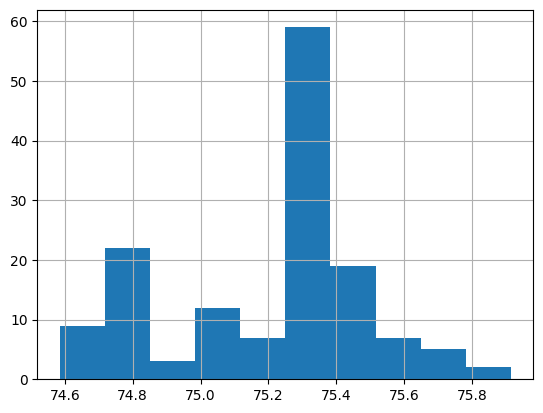

In [292]:
filtered_df_dhar_no_nan["lon"].hist()

In [294]:
filtered_df_dhar_no_nan

,"S,No.",Division,Consumer No.,DTR Capacity,Sanctioned Load (kW),Consumer Name (Name of Office),govt_dept_name,Address,Mobile No.,Average Consumption (kwh),Net Bill,Types of Building,Types of Rooftop RCC/Non RCC,Shadow free area (Sq. Ft.),Solar Rooftop Capacity installed/proposed (In kWp),Latitude & Longitude of premises,lat,lon
0,1,Badnawar,3783009255,63,10,तहसीलदार तहसील ऑफिस,Revenue Department,बड़ी चौपाटी,7.295232e+09,NaN,5910,Pakka,RCC,2400,10.0,"23.022311, 75.2475604.17",23.022311,75.247560
1,2,Badnawar,3783009291,200,105,मेडिकल आफिसर पब्लिक हेल्थ सेन्टर,Public Health & Family Welfare Department,बस स्टेण्ड,9.893875e+09,7041.0,153322,Pakka,RCC,8000,105.0,"23.0218737, 75.2323902.17",23.021874,75.232390
2,3,Badnawar,3783010564,63,50,सचिव कृषि उपज मंण्डी,Farmers Welfare and Agricultural Development D...,बदनावर शहर,7.722992e+09,104214.0,137196,Pakka,RCC,3000,42.0,"23.0182396, 75.2024675.1425",23.018240,75.202467
3,4,Badnawar,3783011288,25,10,ग्रामीण् कृषि विस्तार अधिकारी,Farmers Welfare and Agricultural Development D...,मिटटी परीक्षण प्रयोगशाला,8.120006e+09,NaN,30754,Pakka,RCC,1600,10.0,"23.0270422, 75.2362377",23.027042,75.236238
4,5,Badnawar,3783013806,200,10,प्राचार्या शासकीय महावि‌द्यालय बदनावर,Department of Higher Education,नवीन भवन एकवीरा रोड,9.406822e+09,NaN,5879,Pakka,RCC,2500,10.0,"23.0268754, 75.2273352.21",23.026875,75.227335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,174,Mhow,3689004141,100,10,तहसीलदार महोदया,Revenue Department,मॉडर्न रिकॉर्ड रूम,9.111113e+09,NaN,69806,Govt.,RCC,1800,10.0,"22.152777, 75.351798",22.152777,75.351798
174,175,Mhow,3689009686,200,12,तहसीलदार तहसील ऑफिस,Revenue Department,धरमपुरी,9.893353e+09,NaN,148913,Govt.,RCC,3600,12.0,22.152756. 75.351673,22.152756,75.351673
175,176,Mhow,3606012684,25,10,मेडिकल ऑफिसर,Public Health & Family Welfare Department,प्राथमिक स्वास्थ्य केंद्र गुजरी,8.224029e+09,NaN,57957,Govt.,RCC,2000,10.0,"22.31876, 75.5056",22.318760,75.505600
176,177,Dhar (O&M),H5074904000,315,80,प्राचार्य पी जी कॉलेज धार,Higher Education,नंबर 62 जेतपुर अहमदाबाद इंदौर रोड धार,9.425936e+09,NaN,127925,Govt.,RCC,4000,80.0,"22.6097, 75.3245",22.609700,75.324500


In [293]:
filtered_df_dhar_no_nan.to_csv(SAVE_DIR_DHAR / "cleaned_data.csv", index=False)

## Chhindwara
East Zone DISCOM. Keep highlighted rows.

In [275]:
SAVE_DIR_CHHINDWARA = OUTPUT_DATA_DIR / "Chhindwara"
SAVE_DIR_CHHINDWARA.mkdir(parents=True, exist_ok=True)

worksheet_chhindwara = workbook["Chhindwara"]

df_chhindwara = pd.read_excel(CONSOLIDATED_DATA_PATH, sheet_name="Chhindwara", header=0)
df_chhindwara

,SN,District,DISCOM,Name of institutions/consumer as per billing/connection details,Contact information of consumer,govt_dept_name,IVRS/Consumer Code as per billing details,Latitude/Langitude of location of consumer's permises,Owner ship a of primises (Govt./ Private),Average monthly electricity consumption on of consumer's premises (kWh),...,Contract Demand/ sanctioned load of consumer for target premises (kVA),Contract Demand/ sanctioned load of consumer for target premises (KW),Rated capacity of DTR as per records of Discom (kVA),How much total solar rooftop capacity alredy connected with/ applied for at concerned DTr as per records of Discom (in kW),Possible solar rooftop capacity (in kW) as per Contract Demand (Option -1),Possible solar rooftop capacity (in kW) as per shadow free useful rooftop/groun d area of consumer's premises (Option -2),Possible solar rooftop capacity (in kW) as per monthly consumption (Option -3),Possible solar rooftop capacity (in kW) as per DTR Capacity for solar rooftop (Option -4),"Proposed SPV Plant Capacity (kW) = minimum of C-1, C-2, C-3 and C-4","Critical obseravation/ remarks, if any"
0,1,CHHINDWARA,JABALPUR,S D O TELEPHONE EXCHANGE,,BSNL,1342016220,2.2906834 79.165359,GOVT,2024.67,...,35.0,NaN,63.0,0.0,35.0,20.0,13.50,50.4,13.50,NaN
1,2,CHHINDWARA,JABALPUR,BRANCH MANEGER,NaN,-,1342018607,2.3032795 79.170153,GOVT,1058.80,...,24.0,NaN,200.0,0.0,24.0,20.0,7.06,160.0,7.06,NaN
2,3,CHHINDWARA,JABALPUR,PRINCIPAL GOVT PG COLLAGE,NaN,Department of Higher Education,1342022971,2.3050235 79.152663,GOVT,522.79,...,20.0,20.0,63.0,0.0,20.0,20.0,3.49,50.4,3.49,NaN
3,4,CHHINDWARA,JABALPUR,BLOCK MEDICAL OFFICER,NaN,Public Health & Family Welfare Department,1342017750,2.3062417 79.171475,GOVT,3098.42,...,50.0,50.0,200.0,0.0,50.0,20.0,20.66,160.0,20.00,NaN
4,5,CHHINDWARA,JABALPUR,SHRI NEW CIVIL COURT,9303107125,Law & Legislative Affairs Department,1342000356,2.3059878 79.168829,GOVT,1782.43,...,37.5,30.0,100.0,0.0,37.5,6.0,11.88,80.0,6.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,CHHINDWARA,JABALPUR,GENERAL MANAGER W C F LTD,9406776775,NaN,H4991832000,2.1981319 78.684302,GOVT,154000.00,...,800.0,640.0,1000.0,0.0,800.0,100.0,1026.67,800.0,100.00,NaN
154,155,CHHINDWARA,JABALPUR,GENERAL MANAGER W C F LTD,9406776775,NaN,H7203832000,22..189149 78.705791,GOVT,287000.00,...,1500.0,1200.0,3150.0,0.0,1500.0,400.0,1913.33,2520.0,400.00,NaN
155,156,CHHINDWARA,JABALPUR,MANAGER MOHAN COLLIERY,7587595224,Coal department,H8203832000,22.178109 78.677624,GOVT,243000.00,...,1400.0,1120.0,3150.0,0.0,1400.0,200.0,1620.00,2520.0,200.00,NaN
156,157,CHHINDWARA,JABALPUR,EXECUTIVE ENGINEER PHE,9630526057,Public Health Engineering Department,H8282832000,22.226721 78.687877,GOVT,94400.00,...,400.0,320.0,500.0,0.0,400.0,100.0,629.33,400.0,100.00,NaN


In [276]:
df_chhindwara["Latitude/Langitude of location of consumer's permises"].replace(
    "0", np.nan, inplace=True
)
df_chhindwara["Latitude/Langitude of location of consumer's permises"].replace(
    0, np.nan, inplace=True
)

In [ ]:
df_chhindwara["lat_original"] = df_chhindwara[
    "Latitude/Langitude of location of consumer's permises"
].apply(lambda x: np.nan if pd.isnull(x) else str(x).split(" ")[0])

# fix random double-decimal issue
df_chhindwara["lat_original"] = df_chhindwara["lat_original"].str.replace('..', '.', regex=False)

# change to float
df_chhindwara["lat_original"] = df_chhindwara["lat_original"].astype(float)

# column to keep track of issues
df_chhindwara["lat_problem"] = "unchecked"
df_chhindwara.loc[df_chhindwara["lat_original"].isna(), "lat_problem"] = "missing"
df_chhindwara.loc[df_chhindwara["lat_original"].between(20, 24), "lat_problem"] = "ok"
df_chhindwara.loc[df_chhindwara["lat_original"].between(2, 3), "lat_problem"] = "2.XX"
df_chhindwara.loc[df_chhindwara["lat_original"].between(1, 2), "lat_problem"] = "1.XX"
df_chhindwara.loc[df_chhindwara["lat_original"] > 50, "lat_problem"] = "> 50"

# replace 2.XX with 22.XX values
df_chhindwara.loc[df_chhindwara["lat_original"].astype(float).between(2, 3), "lat_original"] += 20

df_chhindwara["lat_original"].to_list()

In [ ]:
df_chhindwara["lat_problem"].value_counts()

In [ ]:
df_chhindwara[(df_chhindwara["lat_problem"]!="ok")]

In [ ]:
df_chhindwara["lon_original"] = df_chhindwara[
    "Latitude/Langitude of location of consumer's permises"
].apply(lambda x: np.nan if pd.isnull(x) else str(x).split(" ")[1])
df_chhindwara["lon_original"] = df_chhindwara["lon_original"].astype(float)

# track issues
df_chhindwara["lon_problem"] = "unchecked"
df_chhindwara.loc[df_chhindwara["lon_original"].isna(), "lon_problem"] = "missing"
df_chhindwara.loc[df_chhindwara["lon_original"] < 70, "lon_problem"] = "< 70"
df_chhindwara.loc[df_chhindwara["lon_original"] > 100, "lon_problem"] = "> 100"
df_chhindwara.loc[df_chhindwara["lon_original"].between(70, 100), "lon_problem"] = "ok"
df_chhindwara["lon_original"].to_list()

In [ ]:
df_chhindwara["lon_problem"].value_counts()

In [ ]:
# add the lat lon columns from the discoms data with prefix discom_ to the filtered data. The columns to merge on are "IVRS/Consumer Code as per billing details" on the filtered data and "consumer_no" on the discom data
df_chhindwara = df_chhindwara.merge(
    df_east_discom[["consumer_no", "consumer_latitude", "consumer_longitude"]],
    left_on="IVRS/Consumer Code as per billing details",
    right_on="consumer_no",
    how="left",
)
df_chhindwara.rename(
    columns={
        "IVRS/Consumer Code as per billing details": "discom_consumer_no",
        "consumer_latitude": "lat_discom",
        "consumer_longitude": "lon_discom",
    },
    inplace=True,
)
print(df_chhindwara[["discom_consumer_no", "lat_discom", "lon_discom"]].isna().sum())

In [ ]:
# make new columns called "lat" and "lon" that are the lat and lon columns from the filtered data if they are "ok", otherwise they are the lat and lon columns from the discom data
df_chhindwara["lat"] = df_chhindwara.apply(
    lambda row: row["lat_original"]
    if row["lat_problem"] == "ok" or row["lat_problem"] == "2.XX"
    else row["lat_discom"],
    axis=1,
)
df_chhindwara["lon"] = df_chhindwara.apply(
    lambda row: row["lon_original"]
    if row["lon_problem"] == "ok"
    else row["lon_discom"],
    axis=1,
)

In [ ]:
df_chhindwara["lat"].hist()

In [ ]:
df_chhindwara["lon"].hist()

In [ ]:
df_chhindwara

In [ ]:
bad_df_chhindwara = df_chhindwara[
    ~(
        df_chhindwara["lat_problem"].isin(["ok", "2.XX"])
        & df_chhindwara["lon_problem"].isin(["ok"])
    )
]
bad_df_chhindwara

In [ ]:
bad_df_chhindwara[["lat", "lon"]].dropna()
# 6 of the 12 rescued!

In [ ]:
print("Bad buildings: ", len(bad_df_chhindwara), "of", len(df_chhindwara), "total buildings")
print("Rescued buildings: ", len(bad_df_chhindwara[["lat", "lon"]].dropna()))

In [ ]:
df_chhindwara.dropna(subset=["lat", "lon"])

In [ ]:
df_chhindwara_no_nan = df_chhindwara.dropna(
    subset=["lat", "lon"], axis=0
).reset_index(drop=True)

In [ ]:
df_chhindwara_no_nan.to_csv(SAVE_DIR_CHHINDWARA / "cleaned_data.csv", index=False)

### Plot and check

In [ ]:
gdf_chhindwara = gpd.GeoDataFrame(
    df_chhindwara,
    geometry=gpd.points_from_xy(
        df_chhindwara["lon"], df_chhindwara["lat"]
    ),
    crs=INDIA_PROJECTED_CRS,
)
gdf_chhindwara = gdf_chhindwara.to_crs(epsg=4326)

In [ ]:
gdf_chhindwara_discom = gpd.GeoDataFrame(
    df_chhindwara,
    geometry=gpd.points_from_xy(
        df_chhindwara["lon_discom"], df_chhindwara["lat_discom"]
    ),
    crs=INDIA_PROJECTED_CRS,
)
gdf_chhindwara_discom = gdf_chhindwara_discom.to_crs(epsg=4326)

In [ ]:
ax = gdf_chhindwara.plot(
    color="blue",
    marker="o",
    markersize=5,
    label="Improved",
    figsize=(10, 10),
)
gdf_chhindwara_discom.plot(
    color="green",
    marker="o",
    markersize=2,
    label="DISCOM",
    ax=ax,
)
plt.legend()
plt.title("Chhindwara Buildings")
